# Simulações para expansão térmica

- Tô em dúvida quanto ao tempo de termalização.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
plt.style.use('../../mpl_themes/jvc.mplstyle')


```bash
cat log.lammps | sed -n "/Step/,/Loop time/p" | head -n-1 > thermo.out   
```

Detalhes da execução:

- `sed -n "/Step/,/Loop time/p"`:
    - Imprime todas as linhas que começam com "Step" e vão até a linha que contém "Loop time", que marca o fim do bloco de termodinâmica. 
- `head -n-1:`
    - Remove a última linha do resultado, que é a linha "Loop time", deixando apenas os dados das variáveis termodinâmicas. 

Se tiver duas runs, tem que pegar a separação das tabelas e excluir. 

In [8]:
header = 'Step Temp Press Volume KinEng PotEng TotEng'.split(" ")
thermo_file = "thermo.out"
df = pd.DataFrame(np.loadtxt(thermo_file), columns=header)
df


,Step,Temp,Press,Volume,KinEng,PotEng,TotEng
0,0.0,100.000000,3831.7093,2905.4508,3.296134,-785286.19,-785282.90
1,100.0,44.892815,4886.2060,2902.6792,1.479727,-785284.02,-785282.54
2,200.0,59.078940,3791.6273,2906.0810,1.947321,-785283.81,-785281.86
3,300.0,77.118136,3680.5402,2907.5977,2.541917,-785283.60,-785281.06
4,400.0,82.550569,4456.8510,2907.6853,2.720977,-785282.95,-785280.23
...,...,...,...,...,...,...,...
1996,199600.0,95.744051,-2310.2335,2916.2061,3.155852,-785282.95,-785279.80
1997,199700.0,90.874567,-3924.6725,2919.0183,2.995347,-785283.16,-785280.17
1998,199800.0,93.882059,-3559.6396,2919.6245,3.094478,-785283.43,-785280.34
1999,199900.0,99.267747,-3078.6293,2918.6189,3.271998,-785283.25,-785279.97


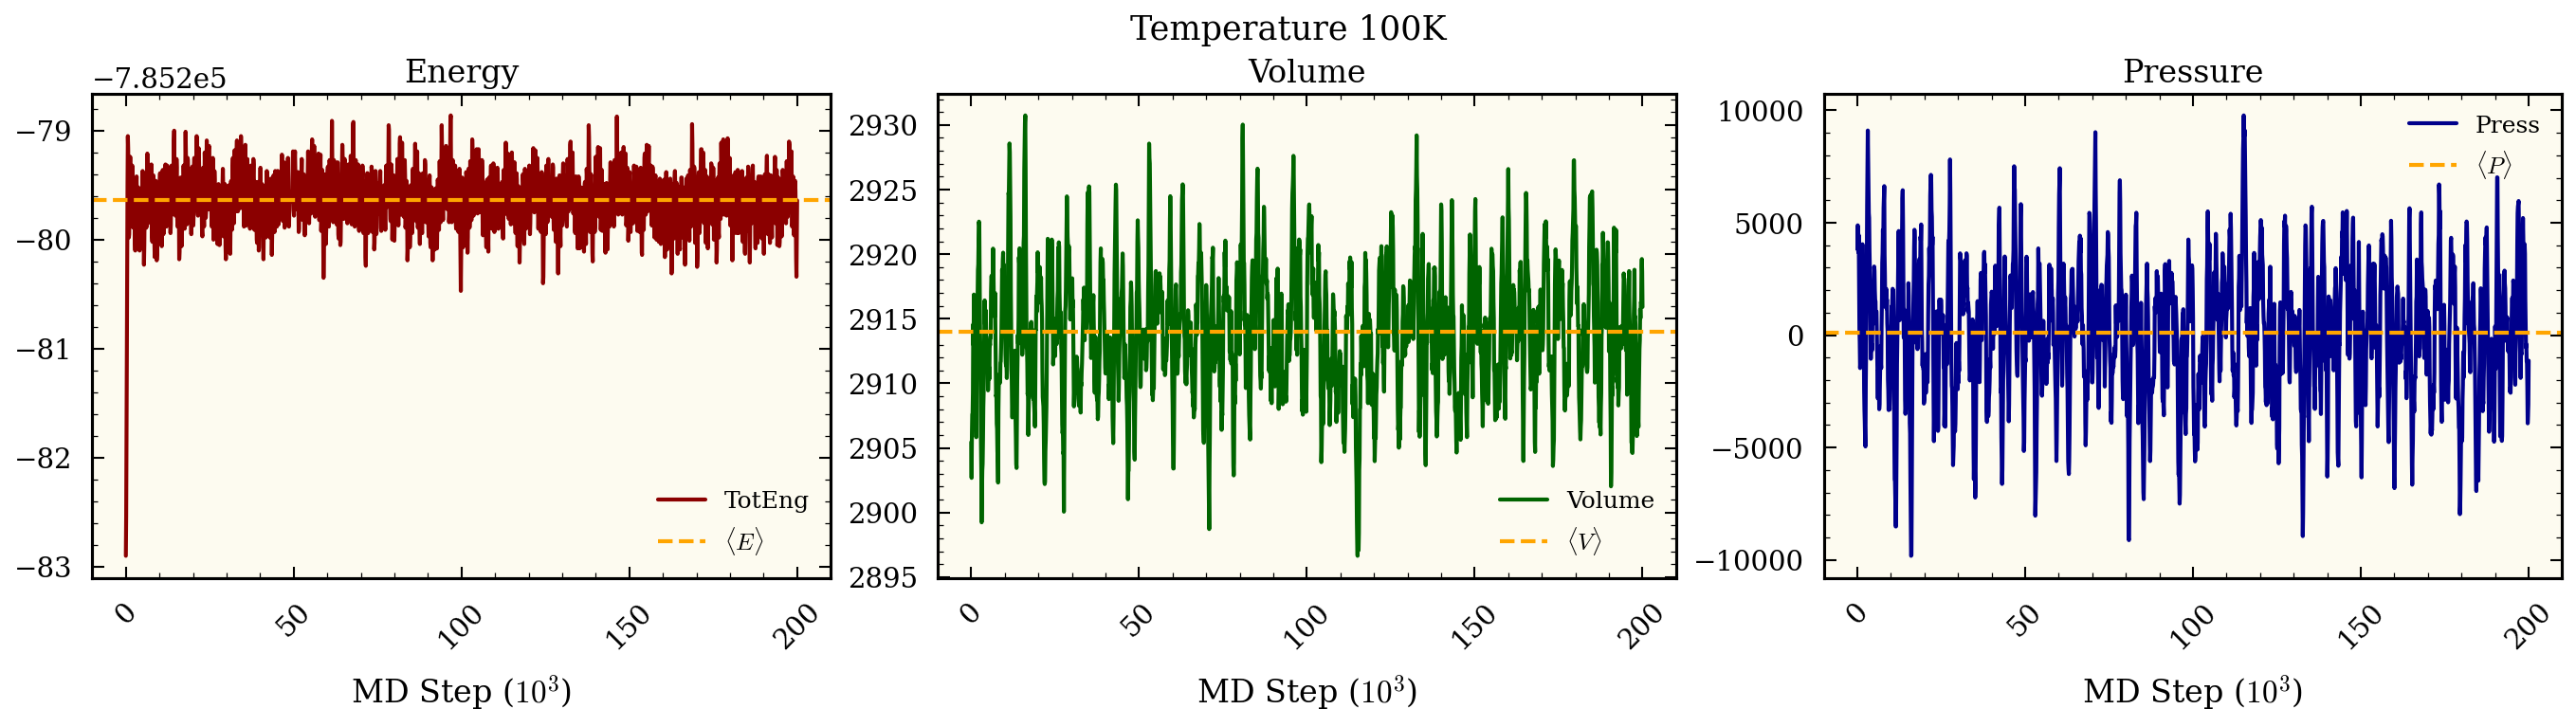

In [22]:
fig, (ax_E, ax_V, ax_P) = plt.subplots(ncols=3, figsize=(18,5), layout='constrained')
fig.suptitle("Temperature 100K")

ax_titles = ["Energy", "Volume", "Pressure"]


df.plot(x='Step', y="TotEng", ax=ax_E, rot=45, color="darkred")
df.plot(x='Step', y="Volume", ax=ax_V, rot=45, color="darkgreen")
df.plot(x='Step', y="Press", ax=ax_P, rot=45, color="darkblue")

for i, ax in enumerate((ax_E, ax_V, ax_P)):
    ax.set_title(ax_titles[i])
    ax.set_xlabel(r"MD Step ($10^3$)")

for ax in (ax_E, ax_V, ax_P):
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1e3)}'))


ax_E.axhline(df["TotEng"].mean(), color='orange', lw=2, ls="--", label=r"$\langle E \rangle$")
ax_P.axhline(df.Press.mean(), color='orange', lw=2, ls="--", label=r"$\langle P \rangle$")
ax_V.axhline(df.Volume.mean(), color='orange', lw=2, ls="--", label=r"$\langle V \rangle$")

ax_E.legend()
ax_P.legend()
ax_V.legend()

plt.show()

In [26]:
df.Volume.mean() / (256 / 2)

22.765532371314343